# Topic-Specific Co-Authorship Analysis

This notebook analyzes the co-authorship network for a single selected topic using `papers_filtered.csv`. It helps answer questions such as:

- who is active in the selected topic,
- how authors are connected under that topic,
- whether the topic network looks tightly knit or externally oriented,
- and which authors appear strongest within that topic slice.


## Environment Check

Run this notebook in the project virtual environment so the local helper module and plotting libraries are available.


In [22]:
import sys
print(sys.executable)


/Users/dharani/Desktop/PSI/env/bin/python


In [23]:
%pip install -r "../requirements.txt"



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Select A Topic

Change `SELECTED_TOPIC` and rerun the notebook to refresh the topic-specific analysis.


In [24]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from scripts.topic_network_analysis import build_topic_report, summary_to_series

SELECTED_TOPIC = "genomics"
DATA_PATH = PROJECT_ROOT / "data" / "papers_filtered.csv"


In [25]:
report = build_topic_report(SELECTED_TOPIC, DATA_PATH)
topic_summary = summary_to_series(report["summary"])
topic_papers_df = report["topic_papers_df"]
topic_authors_df = report["topic_authors_df"]
topic_edges_df = report["topic_edges_df"]
strongest_pairs_df = report["strongest_pairs_df"]

ranking_metrics = [
    "topic_paper_count",
    "topic_degree",
    "topic_weighted_degree",
    "external_neighbors",
    "external_neighbor_share",
    "local_clustering",
]

ranked_topic_authors_df = topic_authors_df[
    (topic_authors_df["topic_paper_count"] >= 2) & (topic_authors_df["topic_degree"] >= 2)
].copy()

for metric in ranking_metrics:
    ranked_topic_authors_df[f"{metric}_pct"] = ranked_topic_authors_df[metric].rank(
        method="average", pct=True
    )

ranked_topic_authors_df["combined_score"] = ranked_topic_authors_df[
    [f"{metric}_pct" for metric in ranking_metrics]
].mean(axis=1)

top_10_authors_df = ranked_topic_authors_df.sort_values(
    [
        "combined_score",
        "topic_paper_count",
        "topic_degree",
        "topic_weighted_degree",
        "external_neighbors",
        "external_neighbor_share",
        "local_clustering",
        "author",
    ],
    ascending=[False, False, False, False, False, False, False, True],
).head(10).reset_index(drop=True)

bottom_10_authors_df = ranked_topic_authors_df.sort_values(
    [
        "combined_score",
        "topic_paper_count",
        "topic_degree",
        "topic_weighted_degree",
        "external_neighbors",
        "external_neighbor_share",
        "local_clustering",
        "author",
    ],
    ascending=[True, True, True, True, True, True, True, True],
).head(10).reset_index(drop=True)

topic_summary


papers_in_topic                                        2548
authors_in_topic_network                               9446
nc_authors_in_topic_network                             924
external_authors_in_topic_network                      8522
coauthor_edges                                       104443
density                                            0.002341
components                                               73
largest_component_size                                 8170
largest_component_share                            0.864916
average_local_clustering                           0.898183
nc_nc_edges                                            2396
nc_external_edges                                     12362
external_external_edges                               89685
cross_nc_external_edge_share                       0.118361
pattern_label                        Core connected network
dtype: object

## Quick Interpretation

This cell generates plain-language conclusions for the selected topic.


In [26]:
top_ranked_author = top_10_authors_df.head(1)
bottom_ranked_author = bottom_10_authors_df.head(1)

interpretation = pd.DataFrame([
    {
        "finding": "Topic size",
        "conclusion": f"The topic {SELECTED_TOPIC!r} currently includes {topic_summary['papers_in_topic']:,} papers and {topic_summary['authors_in_topic_network']:,} authors in the topic-specific co-authorship network."
    },
    {
        "finding": "Network pattern",
        "conclusion": f"This topic is currently classified as {topic_summary['pattern_label']}. The density is {topic_summary['density']:.4f}, the average local clustering is {topic_summary['average_local_clustering']:.3f}, and the largest connected component covers {topic_summary['largest_component_share']:.1%} of the topic network."
    },
    {
        "finding": "Combined ranking rule",
        "conclusion": "Top and bottom author lists combine topic_paper_count, topic_degree, topic_weighted_degree, external_neighbors, external_neighbor_share, and local_clustering after percentile-normalizing each metric. Only authors with at least 2 topic papers and topic degree 2 are included."
    },
    {
        "finding": "Top combined author",
        "conclusion": f"The top-ranked author is {top_ranked_author.iloc[0]['author']} with a combined score of {top_ranked_author.iloc[0]['combined_score']:.3f}, based on topic paper count {int(top_ranked_author.iloc[0]['topic_paper_count'])}, topic degree {int(top_ranked_author.iloc[0]['topic_degree'])}, and weighted degree {int(top_ranked_author.iloc[0]['topic_weighted_degree'])}." if not top_ranked_author.empty else "No author data available for this topic."
    },
    {
        "finding": "Bottom combined author",
        "conclusion": f"The lowest-ranked meaningful author is {bottom_ranked_author.iloc[0]['author']} with a combined score of {bottom_ranked_author.iloc[0]['combined_score']:.3f}. This bottom list excludes one-paper or one-edge cases so it highlights comparatively weaker connected authors rather than trivial isolates." if not bottom_ranked_author.empty else "No bottom-ranked author list is available after filtering."
    },
])
interpretation


,finding,conclusion
0,Topic size,"The topic 'genomics' currently includes 2,548 ..."
1,Network pattern,This topic is currently classified as Core con...
2,Combined ranking rule,Top and bottom author lists combine topic_pape...
3,Top combined author,"The top-ranked author is Groves, Russell L. wi..."
4,Bottom combined author,"The lowest-ranked meaningful author is Hall, S..."


## Top 10 Authors In The Selected Topic


In [27]:
top_10_authors_df[[
    "author",
    "nc_state",
    "combined_score",
    "topic_paper_count",
    "topic_degree",
    "topic_weighted_degree",
    "external_neighbors",
    "external_neighbor_share",
    "local_clustering",
]].assign(
    combined_score=lambda df: df["combined_score"].round(3),
    external_neighbor_share=lambda df: df["external_neighbor_share"].round(3),
    local_clustering=lambda df: df["local_clustering"].round(3),
)


,author,nc_state,combined_score,topic_paper_count,topic_degree,topic_weighted_degree,external_neighbors,external_neighbor_share,local_clustering
0,"Groves, Russell L.",False,0.840,6,211,219,208,0.986,0.589
1,"Thapa, Resham",True,0.837,7,82,117,79,0.963,0.664
2,"Sihi, Debjani",True,0.835,23,196,238,196,1.000,0.380
3,"Holland, J.B.",False,0.835,3,61,98,61,1.000,0.883
4,"Kaeppler, Shawn M.",False,0.824,4,49,78,49,1.000,0.824
5,"Thomison, Peter",False,0.823,4,72,141,71,0.986,0.670
6,"Thompson, Addie",False,0.819,5,78,160,76,0.974,0.606
7,"Schnable, James C.",False,0.819,5,77,158,75,0.974,0.609
8,"Bohn, Martin",False,0.816,6,93,213,90,0.968,0.552
9,"Wallace, Jason",False,0.815,4,73,142,71,0.973,0.660


## Bottom 10 Authors In The Selected Topic


In [28]:
bottom_10_authors_df[[
    "author",
    "nc_state",
    "combined_score",
    "topic_paper_count",
    "topic_degree",
    "topic_weighted_degree",
    "external_neighbors",
    "external_neighbor_share",
    "local_clustering",
]].assign(
    combined_score=lambda df: df["combined_score"].round(3),
    external_neighbor_share=lambda df: df["external_neighbor_share"].round(3),
    local_clustering=lambda df: df["local_clustering"].round(3),
)


,author,nc_state,combined_score,topic_paper_count,topic_degree,topic_weighted_degree,external_neighbors,external_neighbor_share,local_clustering
0,"Hall, Steven",True,0.087,2,5,5,1,0.200,0.400
1,"Aimutis, William R.",False,0.103,2,3,3,2,0.667,0.333
2,"Brown, Zachary S.",False,0.120,2,5,5,3,0.600,0.400
3,"Galik, Christopher",True,0.124,3,5,5,1,0.200,0.200
4,"Thill, Jean-Claude",False,0.125,2,4,4,3,0.750,0.333
5,"Baran, Perver",True,0.128,2,7,7,1,0.143,0.524
6,"Franzluebbers, Alan J.",False,0.129,2,7,7,3,0.429,0.429
7,"Ul Shougat, Md Raf E.",False,0.129,2,5,6,0,0.000,0.600
8,"Doll, Barbara",True,0.132,2,6,6,3,0.500,0.467
9,"Krystal, Andrew",False,0.144,2,4,5,1,0.250,0.667


## Strongest Co-Author Pairs

These are the strongest repeated co-authorship ties inside the selected topic.


In [29]:
strongest_pairs_df.head(20)


,source,target,weight
726,"Chekmenev, Eduard Y.","Theis, Thomas",47
1451,"Jennings, Katherine M.","Jordan, David L.",28
1454,"Jennings, Katherine M.","Monks, David W.",26
15128,"Bozkurt, Alper","Lobaton, Edgar",24
14722,"Bradshaw, Michael","Braun, Uwe",24
14818,"Lee, Bongmook","Misra, Veena",23
11,"Chiang, Vincent L.","Wang, Jack P.",22
24739,"Peters, Kara","Wee, Junghyun",22
1458,"Jordan, David L.","Monks, David W.",21
707,"Theis, Thomas","Warren, Warren S.",21


## Topic Network Plots


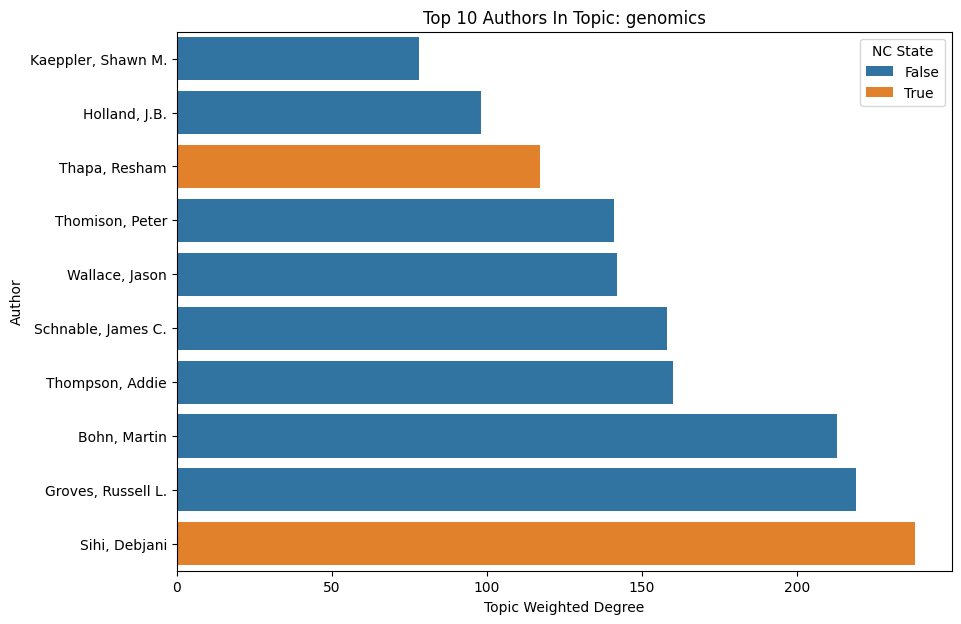

In [30]:
plot_df = top_10_authors_df.sort_values("topic_weighted_degree", ascending=True)
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_df, x="topic_weighted_degree", y="author", hue="nc_state", dodge=False)
plt.title(f"Top 10 Authors In Topic: {SELECTED_TOPIC}")
plt.xlabel("Topic Weighted Degree")
plt.ylabel("Author")
plt.legend(title="NC State")
plt.show()


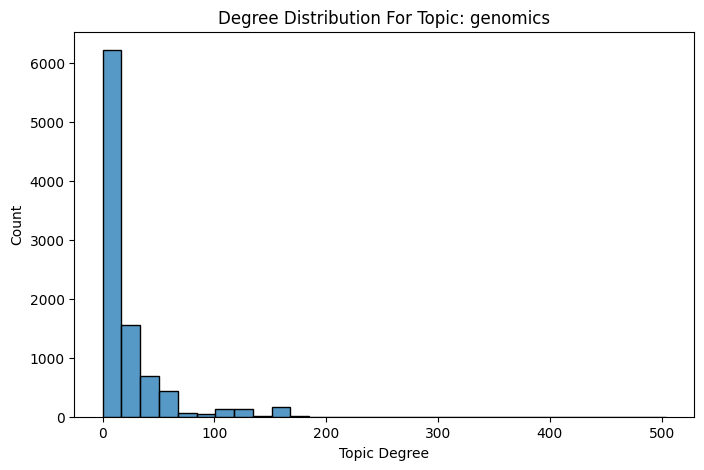

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(topic_authors_df["topic_degree"], bins=30)
plt.title(f"Degree Distribution For Topic: {SELECTED_TOPIC}")
plt.xlabel("Topic Degree")
plt.ylabel("Count")
plt.show()


## Available Topics

Use this list to choose another topic for reruns.


In [32]:
pd.Series(report["available_topics"], name="available_topics")


0                Ag economics
1                      Agtech
2     artificial intelligence
3                  automation
4              bioremediation
               ...           
63               supply chain
64             sustainable ag
65          synthetic biology
66           waste management
67      workforce development
Name: available_topics, Length: 68, dtype: str